In [1]:
# illustrative example of use VeraRubin 

## Making a custom coadd

> Version: 1.0
> 
> Container Size: Large

> Description: In this notebook, we present an illustrative example of the use of the VeraRubin package, where we make a custom coadd from the lsst-distribution.

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
# Complementary info
! echo $IMAGE_DESCRIPTION
! eups list -s | grep lsst_distrib

Release r29.2.0 (RSP Build 2742)
lsst_distrib          gc675d380bf+f75de59d28 	v29_2_0 v29_2_0_rc1 current setup


In [4]:
# Loading modules
import numpy as np
import VeraRubin as vr

# Making a custom-coadd-filter

In [5]:
# Coordinates
# within x-degrees of RA, Dec
ra_deg, dec_deg = (53.2, -27.8)

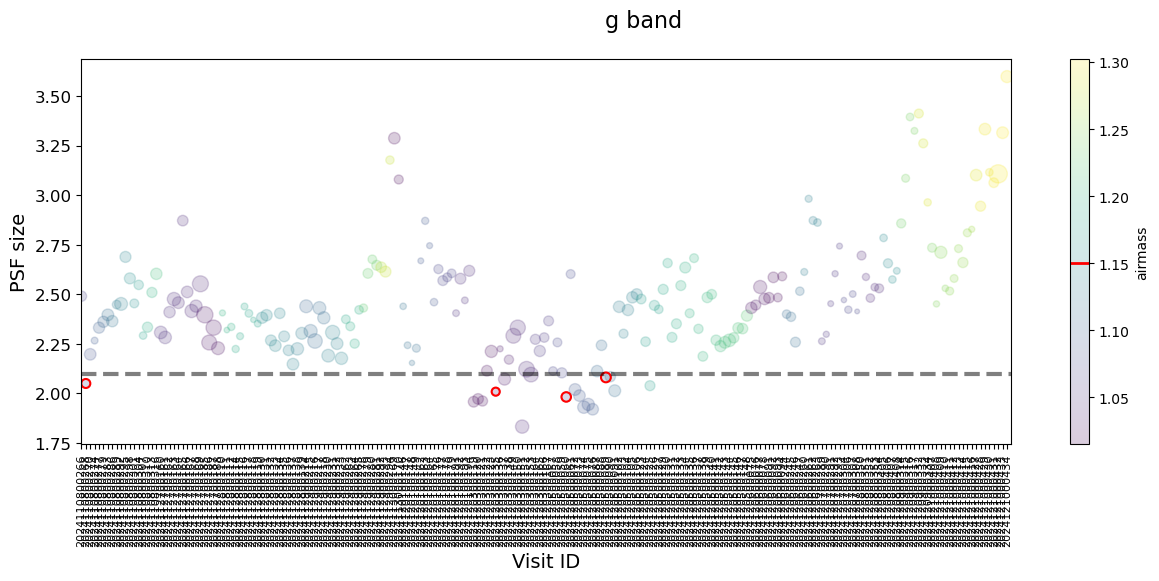

[Warning] NaNs in psfSigma_std for visit 2024121000425
[Warning] NaNs in psfSigma_mean for visit 2024121000425


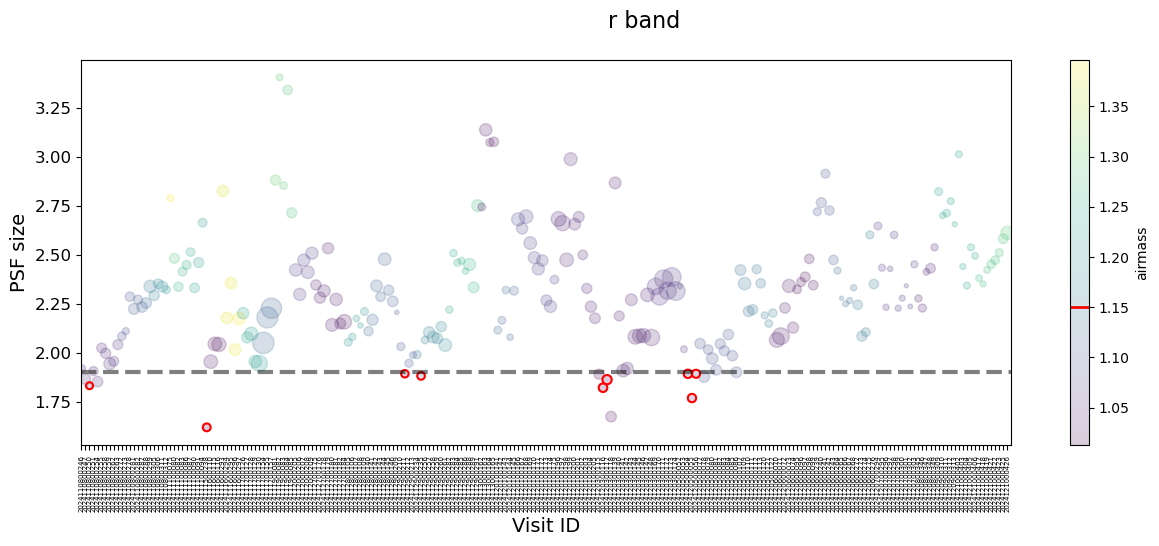

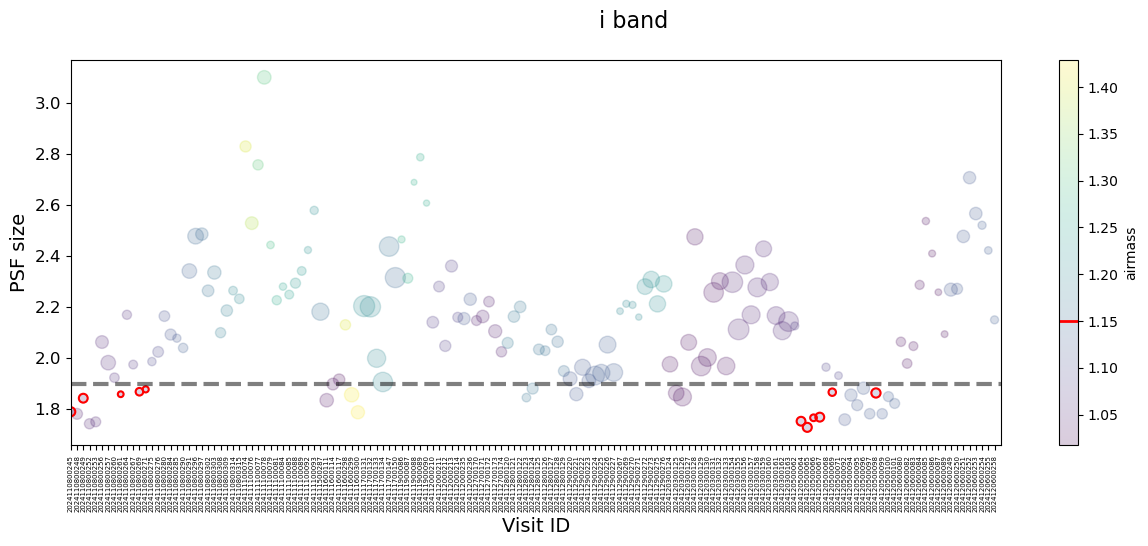

In [ ]:
loc_data = ra_deg, dec_deg

psfSigma_cut, psfStd_cut, airmass_cut = 1.9, 0.05, 1.15

filt_cut = {
    'g': {
    'psfSigma_mean': f' <= {2.1}',
    'psfSigma_std': f' <= {psfStd_cut}',
    'airmass': f' <= {airmass_cut}'
    },
    #
    'r': {
    'psfSigma_mean': f' <= {psfSigma_cut}',
    'psfSigma_std': f' <= {psfStd_cut}',
    'airmass': f' <= {airmass_cut}'
    },
    #
    'i': {
    'psfSigma_mean': f' <= {psfSigma_cut}',
    'psfSigma_std': f' <= {psfStd_cut}',
    'airmass': f' <= {airmass_cut}'
    }
}

# Alternatively, if you can apply the same filter to all bands, you can use:
# filt_cut_select = {
#    'psfSigma_mean': f' <= {psfSigma_cut}',
#    'psfSigma_std': f' <= {psfStd_cut}',
#    'airmass': f' <= {airmass_cut}'
#}
# filt_cut = {name: filt_cut_select for name in bands}

bands = list(filt_cut.keys())
selection = {name: ['psfSigma', 'airmass'] for name in bands}

visits_selected_list, df_metrics_list, coadd_results = vr.custom_coadd_filter(
                    loc_data=loc_data,
                    bands=bands,
                    sky_coordinates=True,
                    butler=None,
                    repository="dp1",
                    collections="LSSTComCam/DP1",
                    skymap_name="lsst_cells_v1",
                    type_coadd='deep_coadd',
                    statistics={'std', 'mean'},
                    selection=selection,
                    filt_cut=filt_cut,
                    plot=True,
                    out=False,
                    my_collection_name='custom_coadd',
                    BUTLER_SAVE_PATH='local_coadd')